# Mini Transformer Encoder–Decoder — From Scratch

This notebook builds a **complete Transformer encoder–decoder** (à la *Attention Is All You Need*) using only `torch.nn.Linear`, `torch.nn.Embedding`, `torch.nn.LayerNorm`, and basic tensor ops — **no `nn.Transformer`, no `nn.MultiheadAttention`**. Every component (scaled dot-product attention, multi-head attention, positional encoding, feed-forward blocks, masking, encoder/decoder stacks) is implemented by hand so you can see exactly what's happening at each step.

We train it on a **toy sequence-to-sequence task: sequence reversal**.

**Task:** given a sequence of random tokens, e.g. `[3, 7, 1, 9, 2]`, output it reversed: `[2, 9, 1, 7, 3]`.

Why this task?
- It's seq2seq (input length ≠ a fixed mapping; in general input/output can even differ in length), so it genuinely exercises the **encoder–decoder cross-attention** mechanism.
- It's trivial to generate infinite labeled data (no dataset to download).
- It's *non-trivial for the model*: to reverse a sequence, the decoder at output step `t` must attend to encoder position `(L - 1 - t)` — a clean, verifiable attention pattern we can visualize at the end to confirm the model actually learned to use attention, not just memorize.

## What you'll find in this notebook
1. Imports & config
2. Toy dataset (sequence reversal) + vocabulary
3. Positional encoding
4. Scaled dot-product attention (from scratch)
5. Multi-head attention (from scratch)
6. Position-wise feed-forward network
7. Encoder layer & Encoder stack
8. Decoder layer & Decoder stack (with masked self-attention + cross-attention)
9. Full Seq2Seq Transformer model
10. Masks (padding mask + causal/look-ahead mask)
11. Training loop
12. Greedy decoding / inference
13. Evaluation on random test sequences
14. Attention visualization (to *prove* it learned the right alignment)


## 1. Imports & Configuration

We keep the model intentionally small ("mini") so it trains in well under a minute on CPU, while still containing every architectural piece of a full Transformer.

| Hyperparameter | Value | Meaning |
|---|---|---|
| `d_model` | 64 | Embedding / hidden dimension |
| `num_heads` | 4 | Number of attention heads (so each head has dim 16) |
| `num_layers` | 2 | Encoder layers and decoder layers (each) |
| `d_ff` | 128 | Inner dimension of the feed-forward block |
| `max_len` | 12 | Max sequence length we'll handle |
| `vocab_size` | 13 | 10 token values (0-9) + `<pad>`, `<bos>`, `<eos>` |


In [1]:
import math
import random
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----- Special tokens -----
PAD, BOS, EOS = 0, 1, 2
NUM_DIGIT_TOKENS = 10                 # digits 0-9 are the "content" vocabulary
VOCAB_SIZE = NUM_DIGIT_TOKENS + 3     # + PAD, BOS, EOS

# ----- Model hyperparameters -----
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 128
DROPOUT = 0.1
MAX_LEN = 14     # generous upper bound used for positional encoding table

print(f"Vocab size: {VOCAB_SIZE}, d_model: {D_MODEL}, heads: {NUM_HEADS}, layers: {NUM_LAYERS}")


Using device: cpu
Vocab size: 13, d_model: 64, heads: 4, layers: 2


## 2. Toy Dataset — Sequence Reversal

Each example:
- **Source**: a random sequence of digit-tokens of random length `L` (between `min_len` and `max_len`), e.g. `[5, 2, 8, 1]`.
- **Target**: the same sequence reversed, with `<bos>` prepended and `<eos>` appended: `[<bos>, 1, 8, 2, 5, <eos>]`.

This `<bos>`/`<eos>` framing is exactly how real seq2seq systems (translation, summarization) are set up: the decoder is taught to start generating after seeing `<bos>` and to learn to emit `<eos>` when it's done.

We pad each batch to the same length with `PAD` tokens and build a `Dataset`/`DataLoader` around it so the training loop looks like a realistic seq2seq pipeline.


In [2]:
from torch.utils.data import Dataset, DataLoader

class ReverseDataset(Dataset):
    '''Generates (source, target) pairs for the sequence-reversal task on the fly.'''
    def __init__(self, num_samples, min_len=3, max_len=8):
        self.num_samples = num_samples
        self.min_len = min_len
        self.max_len = max_len

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        L = random.randint(self.min_len, self.max_len)
        # digit tokens are offset by 3 because 0,1,2 are reserved for PAD,BOS,EOS
        seq = [random.randint(0, NUM_DIGIT_TOKENS - 1) + 3 for _ in range(L)]
        src = seq
        tgt = [BOS] + seq[::-1] + [EOS]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = [len(s) for s in srcs]
    tgt_lens = [len(t) for t in tgts]
    max_src = max(src_lens)
    max_tgt = max(tgt_lens)

    src_padded = torch.full((len(batch), max_src), PAD, dtype=torch.long)
    tgt_padded = torch.full((len(batch), max_tgt), PAD, dtype=torch.long)

    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_padded[i, :len(s)] = s
        tgt_padded[i, :len(t)] = t

    return src_padded, tgt_padded


train_ds = ReverseDataset(num_samples=20000, min_len=3, max_len=8)
val_ds   = ReverseDataset(num_samples=1000,  min_len=3, max_len=8)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)

# quick sanity check
src_sample, tgt_sample = next(iter(train_loader))
print("src batch shape:", src_sample.shape)
print("tgt batch shape:", tgt_sample.shape)
print("\nExample source:", src_sample[0].tolist())
print("Example target:", tgt_sample[0].tolist())
print("(target = <bos>=1, reversed source, <eos>=2, then padding=0)")


src batch shape: torch.Size([64, 8])
tgt batch shape: torch.Size([64, 10])

Example source: [9, 3, 7, 11, 10, 9, 0, 0]
Example target: [1, 9, 10, 11, 7, 3, 9, 2, 0, 0]
(target = <bos>=1, reversed source, <eos>=2, then padding=0)


## 3. Positional Encoding

Self-attention has **no built-in notion of order** — it treats input as a set, not a sequence. The original Transformer fixes this by adding a deterministic **sinusoidal positional encoding** to each token embedding:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Each dimension pair `(2i, 2i+1)` oscillates at a different frequency, so every position gets a unique "fingerprint" vector, and nearby positions get similar fingerprints (smoothly varying), which helps the model generalize to sequence lengths it didn't explicitly see in exactly that form.

We precompute this table once up to `MAX_LEN` and just slice/add it to embeddings at runtime.


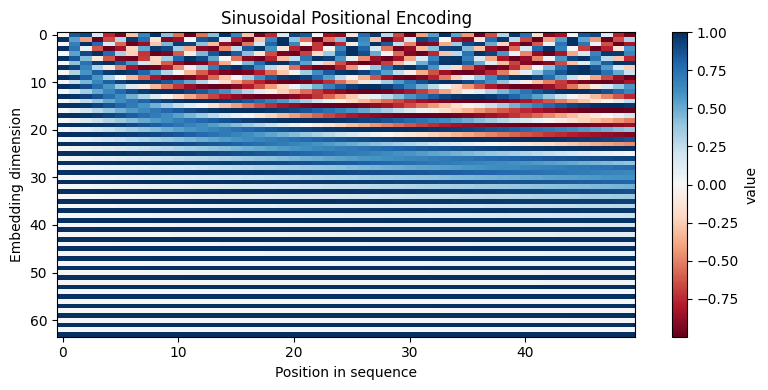

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)        # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)   # (1, max_len, d_model) -> broadcast over batch

        self.register_buffer("pe", pe)   # not a learnable parameter, but moves with .to(device)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)


# Quick visualization of the positional encoding pattern
pe_module = PositionalEncoding(d_model=D_MODEL, max_len=50, dropout=0.0)
pe_matrix = pe_module.pe[0].numpy()

plt.figure(figsize=(8, 4))
plt.imshow(pe_matrix.T, cmap="RdBu", aspect="auto")
plt.xlabel("Position in sequence")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal Positional Encoding")
plt.colorbar(label="value")
plt.tight_layout()
plt.show()


## 4. Scaled Dot-Product Attention

The core operation. Given queries $Q$, keys $K$, values $V$:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

- $QK^\top$ computes a similarity score between every query and every key.
- Dividing by $\sqrt{d_k}$ (the key dimension) keeps the dot products from growing large in magnitude as $d_k$ grows, which would otherwise push softmax into a regime with near-zero gradients.
- `softmax` turns scores into a probability distribution over positions ("how much should I attend to each position?").
- Multiplying by $V$ produces a weighted blend of the value vectors.

**Masking** is applied *before* the softmax, by setting masked-out positions to $-\infty$ (in practice, a very large negative number) so they receive ~0 probability after softmax. We use this for:
- **Padding masks** — so real tokens don't attend to `<pad>` filler.
- **Causal (look-ahead) masks** — so the decoder, when predicting token `t`, cannot peek at tokens `t+1, t+2, ...` (this is what makes autoregressive generation valid at inference time).

We implement this as a free function so both self-attention and cross-attention (encoder–decoder attention) can reuse it.


In [4]:
def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    '''
    query: (batch, num_heads, seq_len_q, d_k)
    key:   (batch, num_heads, seq_len_k, d_k)
    value: (batch, num_heads, seq_len_k, d_v)
    mask:  broadcastable to (batch, num_heads, seq_len_q, seq_len_k); True/1 = keep, False/0 = mask out
    '''
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)   # (batch, heads, seq_q, seq_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-1e9"))

    attn_weights = F.softmax(scores, dim=-1)   # probability distribution over keys, for each query
    if dropout is not None:
        attn_weights = dropout(attn_weights)

    output = torch.matmul(attn_weights, value)  # (batch, heads, seq_q, d_v)
    return output, attn_weights


## 5. Multi-Head Attention

Instead of computing attention once with the full `d_model`-dimensional vectors, we **split into `num_heads` smaller subspaces**, run scaled dot-product attention in parallel in each, then concatenate and project back:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$
$$\text{head}_i = \text{Attention}(QW^Q_i, KW^K_i, VW^V_i)$$

Why multiple heads? A single attention head computes one weighted average per query. Multiple heads let the model attend to **different types of relationships simultaneously** in different subspaces — e.g., one head might learn positional/local patterns, another might learn longer-range content matches.

Implementation trick: rather than having `h` separate small linear layers, we use **one big linear layer** of size `d_model -> d_model` and then `reshape`/`transpose` to split it into `(num_heads, d_k)` chunks — mathematically identical to separate per-head projections, but a single matmul, so it's faster.

This module is written generically to take `query`, `key`, `value` as **separate inputs**, because:
- In **self-attention** (encoder, or decoder masked self-attn), `query = key = value` = the same sequence.
- In **cross-attention** (decoder attending to encoder output), `query` comes from the decoder but `key`/`value` come from the encoder.


In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=DROPOUT):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads   # dimension per head

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)   # output projection after concatenating heads

        self.dropout = nn.Dropout(dropout)
        self.attn_weights = None   # stashed for visualization later

    def split_heads(self, x):
        # x: (batch, seq_len, d_model) -> (batch, num_heads, seq_len, d_k)
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def combine_heads(self, x):
        # x: (batch, num_heads, seq_len, d_k) -> (batch, seq_len, d_model)
        batch_size, _, seq_len, _ = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, self.d_model)

    def forward(self, query, key, value, mask=None):
        Q = self.split_heads(self.W_q(query))   # (batch, heads, seq_q, d_k)
        K = self.split_heads(self.W_k(key))      # (batch, heads, seq_k, d_k)
        V = self.split_heads(self.W_v(value))    # (batch, heads, seq_k, d_k)

        if mask is not None:
            # mask comes in as (batch, 1, seq_q, seq_k) or (batch, 1, 1, seq_k); broadcasts over heads automatically
            pass

        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask=mask, dropout=self.dropout)
        self.attn_weights = attn_weights.detach()   # save (not used in loss) for later visualization

        output = self.combine_heads(attn_output)
        return self.W_o(output)


## 6. Position-wise Feed-Forward Network

After attention mixes information *across* positions, each position is passed through an **identical 2-layer MLP, applied independently to every position**:

$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

This expands to a larger hidden dimension (`d_ff`, here 128 vs `d_model=64`) and back down, giving the model extra capacity to transform each token's representation after attention has gathered context for it. Think of attention as "routing information between positions" and the FFN as "processing the information at each position."


In [6]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=DROPOUT):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


## 7. Encoder Layer & Encoder Stack

Each **encoder layer** has two sub-blocks, each wrapped with a **residual connection** and **layer normalization**:

1. Multi-head **self-attention** (every source token attends to every other source token) → `x = LayerNorm(x + SelfAttn(x))`
2. Position-wise feed-forward → `x = LayerNorm(x + FFN(x))`

We use the **"post-norm"** variant (normalize *after* adding the residual), matching the original paper. Residual connections let gradients flow directly through the network even through many layers (mitigating vanishing gradients), and LayerNorm stabilizes the scale of activations between sub-layers.

The full **Encoder** is just `N` of these layers stacked, applied to the (positionally-encoded) source embeddings. The output is a sequence of contextualized vectors — one per source token — that the decoder will later query via cross-attention.


In [7]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=DROPOUT):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        # --- self-attention sub-block ---
        attn_out = self.self_attn(x, x, x, mask=src_mask)
        x = self.norm1(x + self.dropout(attn_out))      # residual + LayerNorm

        # --- feed-forward sub-block ---
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))        # residual + LayerNorm
        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.d_model = d_model

    def forward(self, src, src_mask):
        # src: (batch, src_len)
        x = self.embedding(src) * math.sqrt(self.d_model)   # scale embeddings (per original paper)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, src_mask)
        return x   # (batch, src_len, d_model) -- contextualized source representations


## 8. Decoder Layer & Decoder Stack

Each **decoder layer** has *three* sub-blocks (vs. the encoder's two):

1. **Masked self-attention** over the target sequence so far — masked with a *causal* mask so position `t` cannot see positions `> t`. This is what enables autoregressive generation: during training we feed the whole shifted target sequence at once ("teacher forcing"), but the causal mask guarantees the model only effectively used past tokens, exactly as it must at inference time.
2. **Cross-attention**: queries come from the decoder's own (causally-masked) representations, but **keys and values come from the encoder output**. This is the literal "encoder-decoder" connection — at every decoder step, the model looks back at the *entire* source sequence and decides which source positions are relevant for producing the current output token.
3. **Feed-forward** — same as in the encoder.

Each sub-block again has its own residual + LayerNorm.

The **Decoder** stack is `N` of these layers, fed the (positionally-encoded) target embeddings, the causal mask, and the encoder's output (+ source padding mask for cross-attention).


In [8]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=DROPOUT):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        # --- masked self-attention over target-so-far ---
        self_attn_out = self.self_attn(x, x, x, mask=tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))

        # --- cross-attention: decoder queries, encoder keys/values ---
        cross_attn_out = self.cross_attn(x, enc_out, enc_out, mask=memory_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))

        # --- feed-forward ---
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.d_model = d_model

    def forward(self, tgt, enc_out, tgt_mask, memory_mask):
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, enc_out, tgt_mask, memory_mask)
        return x   # (batch, tgt_len, d_model)


## 9. Masks

Two distinct masks are needed, and it's worth being precise about each:

**1. Padding mask** (`make_padding_mask`) — marks real tokens as `1` and `<pad>` tokens as `0`. Used for:
   - Encoder self-attention (source padding shouldn't be attended to)
   - Cross-attention (decoder shouldn't attend to source padding either)

**2. Causal / look-ahead mask** (`make_causal_mask`) — a lower-triangular matrix of `1`s. Position `i` is allowed to attend to positions `0..i` only. Used for decoder self-attention.

For the decoder's self-attention we **combine** the target padding mask AND the causal mask (a position must be both a real, non-pad token *and* not in the future) via element-wise AND.

All masks are shaped to broadcast as `(batch, 1, seq_len_q, seq_len_k)` so they apply uniformly across all attention heads.


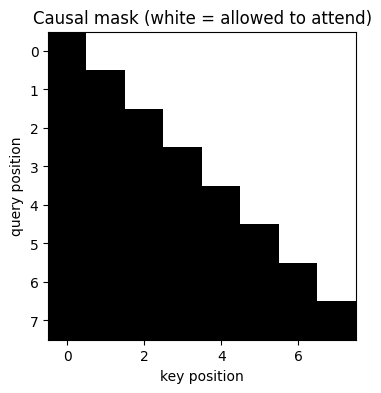

In [9]:
def make_padding_mask(seq, pad_idx=PAD):
    # seq: (batch, seq_len) -> mask: (batch, 1, 1, seq_len), True where NOT pad
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2)


def make_causal_mask(seq_len, device):
    # (1, 1, seq_len, seq_len) lower-triangular matrix of 1s (allowed) and 0s (disallowed/future)
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()
    return mask.unsqueeze(0).unsqueeze(0)


def make_decoder_self_mask(tgt, pad_idx=PAD):
    batch_size, seq_len = tgt.size()
    pad_mask = make_padding_mask(tgt, pad_idx)                 # (batch, 1, 1, seq_len)
    causal_mask = make_causal_mask(seq_len, tgt.device)         # (1, 1, seq_len, seq_len)
    return pad_mask & causal_mask                                # broadcasts -> (batch, 1, seq_len, seq_len)


# --- quick visual sanity check of the causal mask ---
example_mask = make_causal_mask(8, device="cpu")[0, 0].float()
plt.figure(figsize=(4, 4))
plt.imshow(example_mask, cmap="Greys")
plt.title("Causal mask (white = allowed to attend)")
plt.xlabel("key position")
plt.ylabel("query position")
plt.show()


## 10. Full Seq2Seq Transformer

This ties everything together:

```
src tokens --> Encoder --> encoder memory
                                |
tgt tokens --> Decoder (self-attn + cross-attn to memory) --> Linear --> logits over vocab
```

The final `nn.Linear(d_model, vocab_size)` projects each decoder position's hidden vector to a score over the vocabulary — this is the standard "language modeling head" that we'll train with cross-entropy.

We also expose convenience methods `encode()` and `decode_step()` for use during greedy-decoding inference later, plus a `forward()` for training (which decodes the *entire* shifted target sequence at once, relying on the causal mask to make this valid teacher-forcing).


In [10]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=D_MODEL, num_heads=NUM_HEADS,
                 num_layers=NUM_LAYERS, d_ff=D_FF, max_len=MAX_LEN, dropout=DROPOUT):
        super().__init__()
        self.encoder = Encoder(vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout)
        self.decoder = Decoder(vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout)
        self.generator = nn.Linear(d_model, vocab_size)   # final projection to vocab logits

        self._init_weights()

    def _init_weights(self):
        # Xavier init tends to work well for Transformers and speeds up convergence
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask):
        return self.encoder(src, src_mask)

    def decode(self, tgt, enc_out, tgt_mask, memory_mask):
        dec_out = self.decoder(tgt, enc_out, tgt_mask, memory_mask)
        return self.generator(dec_out)   # logits: (batch, tgt_len, vocab_size)

    def forward(self, src, tgt):
        src_mask = make_padding_mask(src)              # for encoder self-attn & cross-attn
        tgt_mask = make_decoder_self_mask(tgt)          # causal + padding, for decoder self-attn

        enc_out = self.encode(src, src_mask)
        logits = self.decode(tgt, enc_out, tgt_mask, src_mask)   # cross-attn uses src_mask as memory_mask
        return logits


model = Seq2SeqTransformer(VOCAB_SIZE).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params:,}")
print(model)


Total trainable parameters: 169,933
Seq2SeqTransformer(
  (encoder): Encoder(
    (embedding): Embedding(13, 64, padding_idx=0)
    (pos_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=64, out_features=64, bias=True)
          (W_k): Linear(in_features=64, out_features=64, bias=True)
          (W_v): Linear(in_features=64, out_features=64, bias=True)
          (W_o): Linear(in_features=64, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): PositionWiseFeedForward(
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): Lay

## 11. Training

**Teacher forcing setup.** For target sequence `[<bos>, t1, t2, ..., tn, <eos>]`:
- **Decoder input**: `[<bos>, t1, t2, ..., tn]` (everything except the last token)
- **Decoder label**: `[t1, t2, ..., tn, <eos>]` (everything except the first token, i.e. shifted by one)

At each position, the decoder input up to and including that position predicts the *next* token — exactly what the causal mask permits and exactly what we want at inference time.

**Loss**: cross-entropy over the vocabulary at every position, with `ignore_index=PAD` so padded positions don't contribute to the loss or its gradient.

**Optimizer**: Adam with a small learning rate plus a linear warmup (a common Transformer recipe; helps stabilize early training when attention patterns are still random) implemented as a simple LambdaLR scheduler.


In [11]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

base_lr = 3e-4
optimizer = torch.optim.Adam(model.parameters(), lr=base_lr, betas=(0.9, 0.98), eps=1e-9)

warmup_steps = 200
def lr_lambda(step):
    step = max(step, 1)
    return min(step / warmup_steps, 1.0)   # linear warmup, then constant

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_epoch(model, loader, optimizer=None, scheduler=None, train=True):
    model.train() if train else model.eval()
    total_loss, total_tokens, total_correct = 0.0, 0, 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)

            decoder_input = tgt[:, :-1]   # drop <eos>/last token
            labels = tgt[:, 1:]            # drop <bos>/first token

            logits = model(src, decoder_input)   # (batch, tgt_len-1, vocab)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            non_pad = labels != PAD
            preds = logits.argmax(-1)
            total_correct += ((preds == labels) & non_pad).sum().item()
            total_tokens += non_pad.sum().item()
            total_loss += loss.item() * non_pad.sum().item()

    avg_loss = total_loss / total_tokens
    accuracy = total_correct / total_tokens
    return avg_loss, accuracy


In [12]:
NUM_EPOCHS = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, scheduler, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")


Epoch  1 | train_loss=1.9766 train_acc=0.2890 | val_loss=1.0376 val_acc=0.6011


Epoch  2 | train_loss=1.1209 train_acc=0.5748 | val_loss=0.4886 val_acc=0.8385


Epoch  3 | train_loss=0.8001 train_acc=0.6989 | val_loss=0.3027 val_acc=0.8942


Epoch  4 | train_loss=0.6061 train_acc=0.7741 | val_loss=0.1444 val_acc=0.9541


Epoch  5 | train_loss=0.4586 train_acc=0.8335 | val_loss=0.0897 val_acc=0.9722


...

Epoch 11 | train_loss=0.1350 train_acc=0.9551 | val_loss=0.0056 val_acc=0.9989


Epoch 12 | train_loss=0.1179 train_acc=0.9615 | val_loss=0.0015 val_acc=1.0000


Epoch 13 | train_loss=0.1011 train_acc=0.9673 | val_loss=0.0022 val_acc=1.0000


Epoch 14 | train_loss=0.0912 train_acc=0.9704 | val_loss=0.0017 val_acc=0.9998


Epoch 15 | train_loss=0.0813 train_acc=0.9739 | val_loss=0.0008 val_acc=0.9998


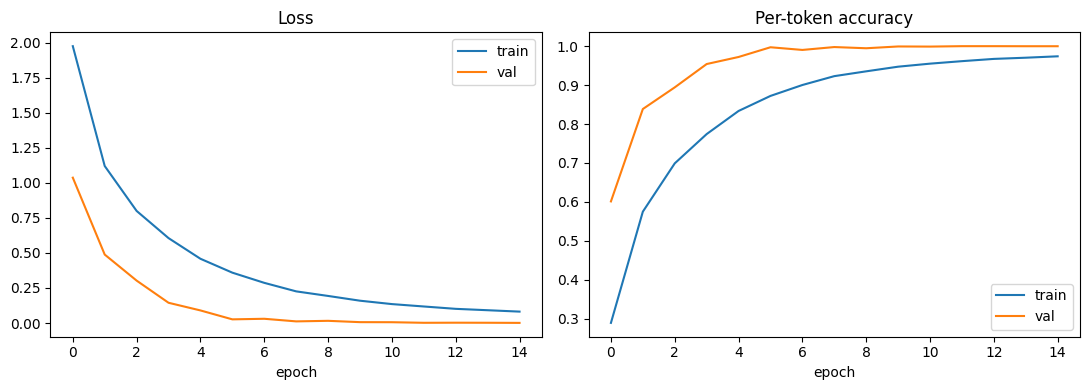

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Per-token accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Inference: Greedy Decoding

At inference time we don't have the target sequence — we generate it **autoregressively**:

1. Encode the source once.
2. Start the decoder input with just `<bos>`.
3. Feed the current (growing) decoder input through the decoder, take the logits at the *last* position, pick the highest-probability token (`argmax` = greedy decoding).
4. Append that token to the decoder input and repeat.
5. Stop when `<eos>` is generated or a max length is reached.

This is the same model and the same `decode()` method used in training — the only difference is *how* we drive it (one token at a time vs. all at once with teacher forcing).


In [14]:
@torch.no_grad()
def greedy_decode(model, src, max_len=20):
    model.eval()
    src = src.to(device)
    if src.dim() == 1:
        src = src.unsqueeze(0)   # add batch dim

    src_mask = make_padding_mask(src)
    enc_out = model.encode(src, src_mask)

    ys = torch.full((src.size(0), 1), BOS, dtype=torch.long, device=device)   # start with <bos>

    for _ in range(max_len - 1):
        tgt_mask = make_decoder_self_mask(ys)
        logits = model.decode(ys, enc_out, tgt_mask, src_mask)   # (batch, cur_len, vocab)
        next_token = logits[:, -1, :].argmax(-1, keepdim=True)    # greedy pick at last position
        ys = torch.cat([ys, next_token], dim=1)

        if (next_token == EOS).all():
            break

    return ys


## 13. Evaluation — Does It Actually Reverse Sequences?

Let's run the trained model on fresh random sequences (never seen during training, since they're sampled on the fly) and check whether the greedily-decoded output exactly matches the true reversal.


In [15]:
def tokens_to_str(tokens):
    '''Render a list/tensor of token ids as digits, stopping at <eos>, skipping special tokens.'''
    out = []
    for t in tokens:
        t = int(t)
        if t == EOS:
            break
        if t in (PAD, BOS):
            continue
        out.append(str(t - 3))   # undo the +3 offset to get back the original digit
    return "".join(out)


def evaluate_examples(model, n=10, min_len=3, max_len=8):
    model.eval()
    correct = 0
    print(f"{'Input':<12} {'Target':<12} {'Predicted':<12} {'Match'}")
    print("-" * 48)
    for _ in range(n):
        L = random.randint(min_len, max_len)
        seq = [random.randint(0, NUM_DIGIT_TOKENS - 1) + 3 for _ in range(L)]
        src = torch.tensor(seq, dtype=torch.long)
        target_str = tokens_to_str(seq[::-1])

        pred_tokens = greedy_decode(model, src, max_len=max_len + 5)[0].tolist()
        pred_str = tokens_to_str(pred_tokens)

        match = (pred_str == target_str)
        correct += match
        src_str = tokens_to_str(seq)
        print(f"{src_str:<12} {target_str:<12} {pred_str:<12} {'✓' if match else '✗'}")

    print("-" * 48)
    print(f"Exact-match accuracy on {n} random examples: {correct}/{n}")


evaluate_examples(model, n=15)


Input        Target       Predicted    Match
------------------------------------------------
309583       385903       385903       ✓
138317       713831       713831       ✓
71828        82817        82817        ✓
3161         1613         1613         ✓
4677502      2057764      2057764      ✓
1478008      8008741      8008741      ✓
810          018          018          ✓
4002         2004         2004         ✓
787772       277787       277787       ✓
6526         6256         6256         ✓
6702249      9422076      9422076      ✓
5047         7405         7405         ✓
157          751          751          ✓
001900       009100       009100       ✓
45269        96254        96254        ✓
------------------------------------------------
Exact-match accuracy on 15 random examples: 15/15


In [16]:
# Larger-scale exact-match evaluation, including lengths slightly beyond the training range
# (a nice probe of length-generalization, since positional encodings are well-defined up to MAX_LEN)
def exact_match_accuracy(model, n_samples=500, min_len=3, max_len=8):
    model.eval()
    correct = 0
    for _ in range(n_samples):
        L = random.randint(min_len, max_len)
        seq = [random.randint(0, NUM_DIGIT_TOKENS - 1) + 3 for _ in range(L)]
        src = torch.tensor(seq, dtype=torch.long)
        target_str = tokens_to_str(seq[::-1])
        pred_tokens = greedy_decode(model, src, max_len=max_len + 5)[0].tolist()
        pred_str = tokens_to_str(pred_tokens)
        correct += (pred_str == target_str)
    return correct / n_samples


acc_in_range = exact_match_accuracy(model, n_samples=500, min_len=3, max_len=8)
print(f"Exact-match accuracy, lengths 3-8 (training range): {acc_in_range:.2%}")

acc_longer = exact_match_accuracy(model, n_samples=500, min_len=9, max_len=11)
print(f"Exact-match accuracy, lengths 9-11 (longer than training): {acc_longer:.2%}")


Exact-match accuracy, lengths 3-8 (training range): 100.00%


Exact-match accuracy, lengths 9-11 (longer than training): 4.60%


## 14. Visualizing Attention — Proof It Learned the Right Alignment

The most convincing evidence that the model learned a real algorithm (not just memorized noise) is to look at its **cross-attention weights**: for the reversal task, we *expect* decoder output position `t` to attend most strongly to **encoder input position `(L - 1 - t)`** — i.e., an anti-diagonal pattern.

We stashed attention weights on every `MultiHeadAttention` module during the forward pass (`self.attn_weights`), so we can grab them straight from the last decoder layer's cross-attention module after a forward pass and plot them as a heatmap.


Input sequence (digits): [6, 9, 7, 1, 0, 1, 2]


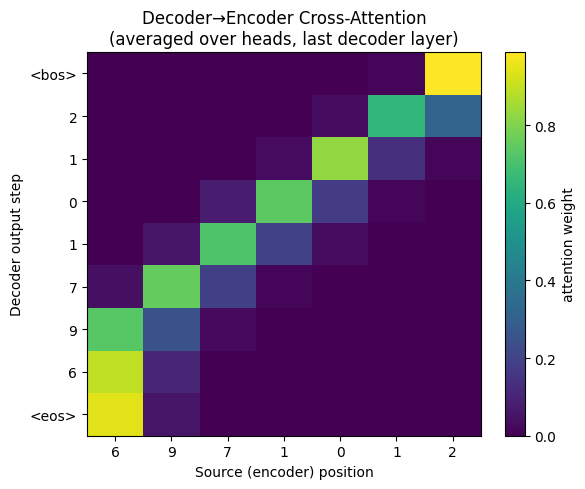

In [17]:
def plot_cross_attention(model, seq):
    model.eval()
    src = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
    src_mask = make_padding_mask(src)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)
        ys = greedy_decode(model, src.squeeze(0), max_len=len(seq) + 5)
        tgt_mask = make_decoder_self_mask(ys)
        _ = model.decode(ys, enc_out, tgt_mask, src_mask)   # forward pass populates attn_weights

    # grab cross-attention weights from the LAST decoder layer, average over heads
    cross_attn = model.decoder.layers[-1].cross_attn.attn_weights[0]   # (heads, tgt_len, src_len)
    avg_attn = cross_attn.mean(dim=0).cpu().numpy()                     # (tgt_len, src_len)

    src_labels = [str(s - 3) for s in seq]
    pred_tokens = ys[0].tolist()
    tgt_labels = []
    for t in pred_tokens:
        if t == BOS:
            tgt_labels.append("<bos>")
        elif t == EOS:
            tgt_labels.append("<eos>")
            break
        else:
            tgt_labels.append(str(t - 3))

    avg_attn = avg_attn[:len(tgt_labels), :]

    plt.figure(figsize=(6, 5))
    plt.imshow(avg_attn, cmap="viridis", aspect="auto")
    plt.xticks(range(len(src_labels)), src_labels)
    plt.yticks(range(len(tgt_labels)), tgt_labels)
    plt.xlabel("Source (encoder) position")
    plt.ylabel("Decoder output step")
    plt.title("Decoder→Encoder Cross-Attention\n(averaged over heads, last decoder layer)")
    plt.colorbar(label="attention weight")
    plt.tight_layout()
    plt.show()


# Try it on a fresh example — look for the anti-diagonal pattern!
example_seq = [random.randint(0, NUM_DIGIT_TOKENS - 1) + 3 for _ in range(7)]
print("Input sequence (digits):", [s - 3 for s in example_seq])
plot_cross_attention(model, example_seq)


## Summary & What to Try Next

You've built, from raw tensor ops, every piece of a Transformer encoder–decoder:

- ✅ Scaled dot-product attention
- ✅ Multi-head attention (used 3 different ways: encoder self-attn, decoder masked self-attn, decoder–encoder cross-attn)
- ✅ Sinusoidal positional encoding
- ✅ Position-wise feed-forward sub-layers
- ✅ Residual connections + LayerNorm ("post-norm" Transformer block)
- ✅ Padding masks and causal masks
- ✅ Teacher-forced training with shifted targets
- ✅ Greedy autoregressive decoding at inference time
- ✅ Attention-weight visualization to sanity-check *what the model actually learned*, not just whether it got the right answer

**Things to experiment with:**
- **Harder tasks**: sorting a sequence, copying, a tiny "addition" task (`"23+45"` → `"68"`), or simple character-level translation between two synthetic "languages."
- **Beam search** instead of greedy decoding — usually a modest accuracy boost on harder tasks.
- **Pre-norm vs. post-norm**: swap `LayerNorm` to before the sub-layer (`x = x + SubLayer(LayerNorm(x))`) — this is what most modern LLMs use, and tends to train more stably at larger scale.
- **Label smoothing** in the loss — a small regularization trick from the original paper.
- **Scale up**: increase `d_model`, `num_heads`, `num_layers`, and watch how much faster/more reliably it converges on harder tasks.
